In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2",
                                        output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6359.82it/s]


Ready!


In [2]:
# IOI sentences
# Sentence A — original
sentence_a = "John gave Mary the book and then John gave"
# Sentence B — different subject
sentence_b = "Tom gave Mary the book and then Tom gave"

# Correct answer
# A mein → "Mary" (John ne Mary ko diya)
# B mein → "Mary" (Tom ne Mary ko diya)
# Dono mein Mary correct hai!

inputs_a = tokenizer(sentence_a, return_tensors="pt")
inputs_b = tokenizer(sentence_b, return_tensors="pt")

tokens_a = tokenizer.convert_ids_to_tokens(inputs_a['input_ids'][0])
tokens_b = tokenizer.convert_ids_to_tokens(inputs_b['input_ids'][0])

print(f"Sentence A: {sentence_a}")
print(f"Tokens A:   {tokens_a}")
print(f"\nSentence B: {sentence_b}")
print(f"Tokens B:   {tokens_b}")

# Normal predictions
with torch.no_grad():
    out_a = model(**inputs_a)
    out_b = model(**inputs_b)

probs_a = torch.softmax(out_a.logits[0, -1, :], dim=0)
probs_b = torch.softmax(out_b.logits[0, -1, :], dim=0)

print(f"\nNormal prediction A: '{tokenizer.decode([probs_a.argmax()])}'")
print(f"Normal prediction B: '{tokenizer.decode([probs_b.argmax()])}'")

# Mary ki probability
mary_id = tokenizer.encode(" Mary")[0]
print(f"\nP(Mary) in A: {probs_a[mary_id]:.4f}")
print(f"P(Mary) in B: {probs_b[mary_id]:.4f}")

Sentence A: John gave Mary the book and then John gave
Tokens A:   ['John', 'Ġgave', 'ĠMary', 'Ġthe', 'Ġbook', 'Ġand', 'Ġthen', 'ĠJohn', 'Ġgave']

Sentence B: Tom gave Mary the book and then Tom gave
Tokens B:   ['Tom', 'Ġgave', 'ĠMary', 'Ġthe', 'Ġbook', 'Ġand', 'Ġthen', 'ĠTom', 'Ġgave']

Normal prediction A: ' her'
Normal prediction B: ' Mary'

P(Mary) in A: 0.2258
P(Mary) in B: 0.2510


In [3]:
# Output structure check karo
with torch.no_grad():
    outputs_a = model(**inputs_a, output_hidden_states=True)

print(f"Hidden states count: {len(outputs_a.hidden_states)}")
print(f"Hidden state 0 shape: {outputs_a.hidden_states[0].shape}")

# Block output check karo
test_acts = {}
def test_hook(module, input, output):
    test_acts['output'] = output
    test_acts['type']   = type(output)
    if isinstance(output, tuple):
        test_acts['len'] = len(output)
        for i, o in enumerate(output):
            if hasattr(o, 'shape'):
                print(f"  output[{i}] shape: {o.shape}")

hook = model.transformer.h[0].register_forward_hook(test_hook)
with torch.no_grad():
    model(**inputs_a)
hook.remove()

print(f"\nBlock output type: {test_acts['type']}")

Hidden states count: 13
Hidden state 0 shape: torch.Size([1, 9, 768])

Block output type: <class 'torch.Tensor'>


In [4]:

hidden_states_a = {}

def make_capture_hook(layer_idx):
    def hook(module, input, output):
        hidden_states_a[layer_idx] = output.detach().clone()
    return hook

# Capture hooks lagao
capture_hooks = []
for i in range(12):
    h = model.transformer.h[i].register_forward_hook(make_capture_hook(i))
    capture_hooks.append(h)

with torch.no_grad():
    out_a = model(**inputs_a)

for h in capture_hooks:
    h.remove()

print(f"Captured {len(hidden_states_a)} layers")
print(f"Shape: {hidden_states_a[0].shape}")


patch_results = []

for layer_idx in range(12):
    target = hidden_states_a[layer_idx].clone()
    
    def patch_hook(module, input, output):
        return target
    
    hook = model.transformer.h[layer_idx].register_forward_hook(patch_hook)
    
    with torch.no_grad():
        patched_out = model(**inputs_b)
    
    hook.remove()
    
    patched_probs = torch.softmax(patched_out.logits[0, -1, :], dim=0)
    mary_prob     = patched_probs[mary_id].item()
    top_word      = tokenizer.decode([patched_probs.argmax().item()])
    
    patch_results.append((layer_idx, mary_prob, top_word))
    print(f"L{layer_idx+1:<3}: P(Mary)={mary_prob:.4f} Top='{top_word}'")

print(f"\nBaseline P(Mary) in B: {probs_b[mary_id]:.4f}")

Captured 12 layers
Shape: torch.Size([1, 9, 768])
L1  : P(Mary)=0.2258 Top=' her'
L2  : P(Mary)=0.2258 Top=' her'
L3  : P(Mary)=0.2258 Top=' her'
L4  : P(Mary)=0.2258 Top=' her'
L5  : P(Mary)=0.2258 Top=' her'
L6  : P(Mary)=0.2258 Top=' her'
L7  : P(Mary)=0.2258 Top=' her'
L8  : P(Mary)=0.2258 Top=' her'
L9  : P(Mary)=0.2258 Top=' her'
L10 : P(Mary)=0.2258 Top=' her'
L11 : P(Mary)=0.2258 Top=' her'
L12 : P(Mary)=0.2258 Top=' her'

Baseline P(Mary) in B: 0.2510


In [5]:
patch_results = []

for layer_idx in range(12):
    target = hidden_states_a[layer_idx].clone()
    
    def patch_hook(module, input, output):
        # Sirf last token patch karo
        patched = output.clone()
        patched[0, -1, :] = target[0, -1, :]
        return patched
    
    hook = model.transformer.h[layer_idx].register_forward_hook(patch_hook)
    
    with torch.no_grad():
        patched_out = model(**inputs_b)
    
    hook.remove()
    
    patched_probs = torch.softmax(patched_out.logits[0, -1, :], dim=0)
    mary_prob     = patched_probs[mary_id].item()
    top_word      = tokenizer.decode([patched_probs.argmax().item()])
    
    patch_results.append((layer_idx, mary_prob, top_word))
    print(f"L{layer_idx+1:<3}: P(Mary)={mary_prob:.4f} Top='{top_word}'")

print(f"\nBaseline A P(Mary): {probs_a[mary_id]:.4f}")
print(f"Baseline B P(Mary): {probs_b[mary_id]:.4f}")

L1  : P(Mary)=0.2570 Top=' Mary'
L2  : P(Mary)=0.2642 Top=' Mary'
L3  : P(Mary)=0.2664 Top=' Mary'
L4  : P(Mary)=0.2711 Top=' Mary'
L5  : P(Mary)=0.2917 Top=' Mary'
L6  : P(Mary)=0.3098 Top=' Mary'
L7  : P(Mary)=0.3218 Top=' Mary'
L8  : P(Mary)=0.3200 Top=' Mary'
L9  : P(Mary)=0.2396 Top=' her'
L10 : P(Mary)=0.1890 Top=' her'
L11 : P(Mary)=0.1963 Top=' her'
L12 : P(Mary)=0.2258 Top=' her'

Baseline A P(Mary): 0.2258
Baseline B P(Mary): 0.2510


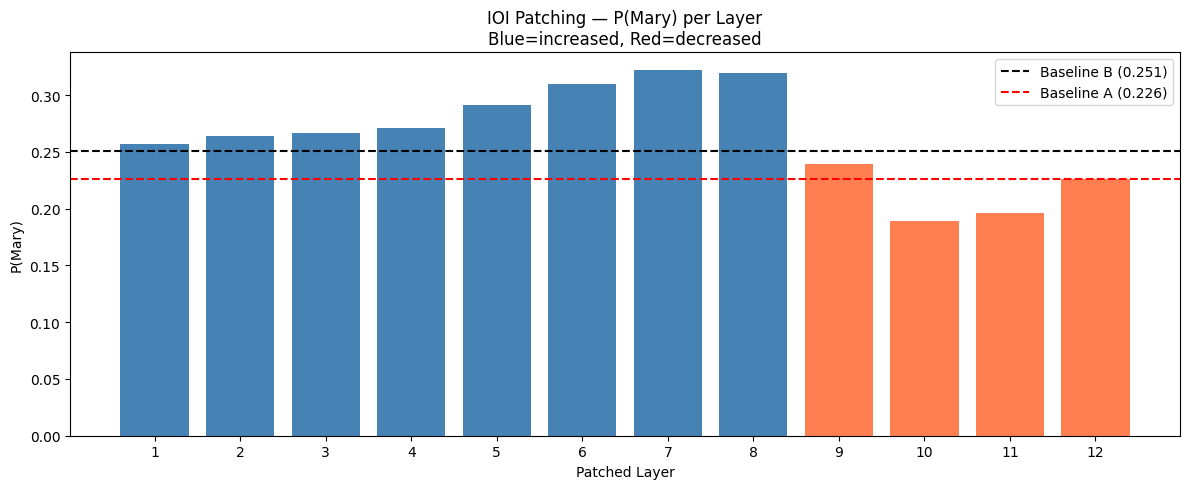

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

layers    = [r[0]+1 for r in patch_results]
mary_probs = [r[1] for r in patch_results]
colors    = ["steelblue" if p > probs_b[mary_id].item() 
             else "coral" for p in mary_probs]

ax.bar(layers, mary_probs, color=colors)
ax.axhline(y=probs_b[mary_id].item(), 
           color="black", linestyle="--",
           label=f"Baseline B ({probs_b[mary_id]:.3f})")
ax.axhline(y=probs_a[mary_id].item(),
           color="red", linestyle="--",
           label=f"Baseline A ({probs_a[mary_id]:.3f})")

ax.set_xlabel("Patched Layer")
ax.set_ylabel("P(Mary)")
ax.set_title("IOI Patching — P(Mary) per Layer\n"
             "Blue=increased, Red=decreased")
ax.legend()
ax.set_xticks(layers)

plt.tight_layout()
plt.show()


* Layer 7 is the most important for IOI (P(Mary) = 0.32!).
* Early and middle layers (1–8) carry information about “Mary.”
* Late layers (9–12) decide between “her” and “Mary.”
* Activation patching reveals which layers are important.
